In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:


df_panel = pd.read_csv(
    r"C:\Users\robin\Documents\Chicago Q2 Winter 26\Python & SQL\final project\macro_panel_quarterly.csv"
)

print(df_panel.head())
print(df_panel.info())

  quarter  debt_gdp country  ca_gdp  gdp_growth      gdp       reer   spreads
0  2000Q1      70.8      AT   845.0         NaN  62062.3  96.300000  0.243120
1  2000Q2      71.4      AT -1329.0    0.011353  62770.9  95.533333  0.289966
2  2000Q3      72.0      AT  -692.0    0.013988  63655.1  94.976667  0.322147
3  2000Q4      66.6      AT  -332.0    0.006756  64086.6  94.560000  0.310531
4  2001Q1      70.4      AT   582.0   -0.003015  63893.7  96.223333  0.319630
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1223 entries, 0 to 1222
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   quarter     1223 non-null   object 
 1   debt_gdp    1200 non-null   float64
 2   country     1223 non-null   object 
 3   ca_gdp      1159 non-null   float64
 4   gdp_growth  1188 non-null   float64
 5   gdp         1223 non-null   float64
 6   reer        1200 non-null   float64
 7   spreads     1100 non-null   float64
dtypes: float64(

In [2]:
df_panel["quarter"] = pd.PeriodIndex(df_panel["quarter"], freq="Q")

# Drop rows with missing core variables
df_panel = df_panel.dropna(subset=[
    "debt_gdp", "ca_gdp", "gdp_growth", "reer", "spreads"
])

In [3]:
country_features = (
    df_panel
    .groupby("country")[["debt_gdp", "ca_gdp", "gdp_growth", "reer", "spreads"]]
    .mean()
)

print(country_features.head())

           debt_gdp       ca_gdp  gdp_growth        reer   spreads
country                                                           
AT        77.418182  1496.545455    0.003353   98.313165  0.349789
BE       103.481818   633.318182    0.003865   98.961818  0.516226
ES        77.783838 -3222.363636    0.004125  101.000774  1.034354
FI        56.006061   447.137273    0.002798  101.884512  0.275871
FR        87.346465 -1632.474747    0.003131  103.084310  0.365573


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(country_features)

In [5]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratios:")
print(pca.explained_variance_ratio_)

Explained variance ratios:
[0.50974395 0.28198634 0.14094008 0.03713599 0.03019364]


In [7]:


for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    print(f"k={k}, silhouette={score:.3f}")

k=2, silhouette=0.259
k=3, silhouette=0.196
k=4, silhouette=0.083
k=5, silhouette=0.098
k=6, silhouette=0.132


In [8]:
kmeans = KMeans(n_clusters=3, random_state=42)
country_features["cluster"] = kmeans.fit_predict(X_pca)

print(country_features.sort_values("cluster"))

           debt_gdp        ca_gdp  gdp_growth        reer   spreads  cluster
country                                                                     
ES        77.783838  -3222.363636    0.004125  101.000774  1.034354        0
IT       124.510101    865.363636    0.001030  103.187609  1.347745        0
GR       152.886957  -3606.619565    0.000946  105.781268  4.207104        0
FR        87.346465  -1632.474747    0.003131  103.084310  0.365573        0
PT        99.645455  -1672.444444    0.002416  101.410909  1.775371        0
IE        60.171739   1165.934239    0.012421  108.080000  1.143401        1
AT        77.418182   1496.545455    0.003353   98.313165  0.349789        2
FI        56.006061    447.137273    0.002798  101.884512  0.275871        2
BE       103.481818    633.318182    0.003865   98.961818  0.516226        2
LU        17.021212    745.698710    0.005592   98.704276  0.099967        2
NL        54.229885  13495.287356    0.003806  100.212184  0.216185        2

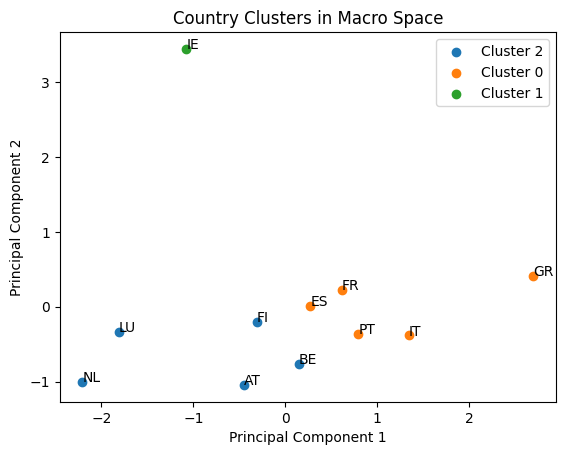

In [ ]:


# Use fundamentals only (recommended)
features = country_features[[
    "debt_gdp", "ca_gdp", "gdp_growth", "reer"
]]

# Standardize
X_scaled = StandardScaler().fit_transform(features)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.figure()
for cluster in country_features["cluster"].unique():
    idx = country_features["cluster"] == cluster
    plt.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        label=f"Cluster {cluster}"
    )

# Add country labels
for i, country in enumerate(country_features.index):
    plt.text(X_pca[i, 0], X_pca[i, 1], country)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Country Clusters in Macro Space")
plt.legend()
plt.show()

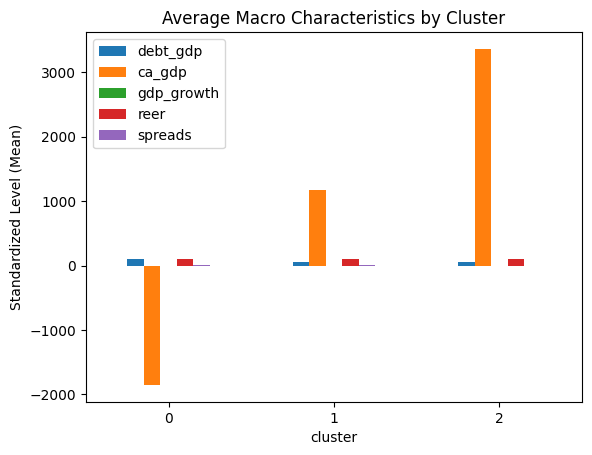

In [10]:
cluster_means = country_features.groupby("cluster").mean()

cluster_means.plot(kind="bar")
plt.title("Average Macro Characteristics by Cluster")
plt.ylabel("Standardized Level (Mean)")
plt.xticks(rotation=0)
plt.show()

<Figure size 800x500 with 0 Axes>

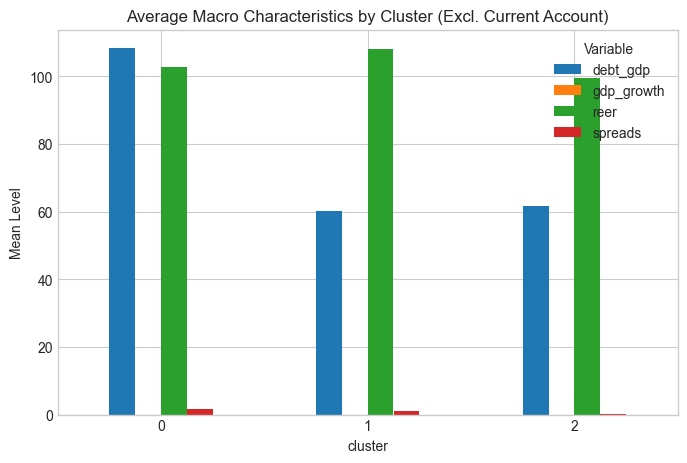

In [15]:


# Select variables WITHOUT current account
cluster_means = (
    country_features
    .groupby("cluster")[["debt_gdp", "gdp_growth", "reer", "spreads"]]
    .mean()
)

# Plot
plt.figure()
cluster_means.plot(kind="bar")

plt.title("Average Macro Characteristics by Cluster (Excl. Current Account)")
plt.ylabel("Mean Level")
plt.xticks(rotation=0)
plt.legend(title="Variable")
plt.show()

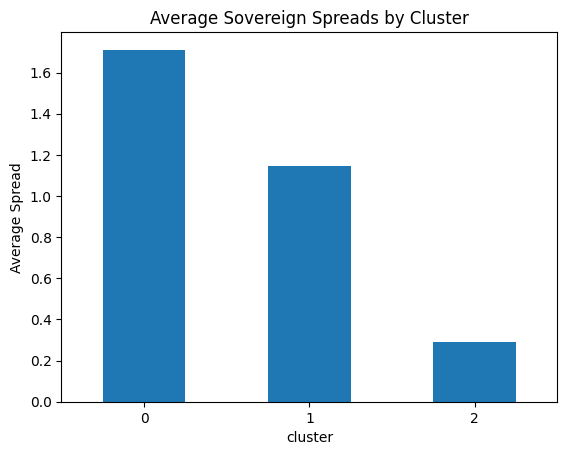

In [11]:
df_panel = df_panel.merge(
    country_features["cluster"],
    on="country"
)

spread_cluster = df_panel.groupby("cluster")["spreads"].mean()

spread_cluster.plot(kind="bar")
plt.title("Average Sovereign Spreads by Cluster")
plt.ylabel("Average Spread")
plt.xticks(rotation=0)
plt.show()

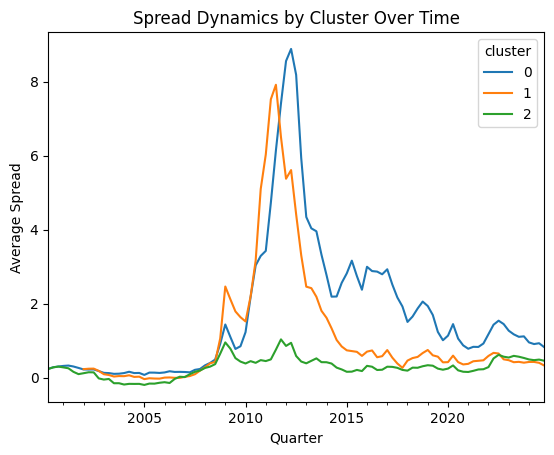

In [12]:
spread_time = (
    df_panel
    .groupby(["quarter", "cluster"])["spreads"]
    .mean()
    .unstack()
)

spread_time.plot()
plt.title("Spread Dynamics by Cluster Over Time")
plt.ylabel("Average Spread")
plt.xlabel("Quarter")
plt.show()